# Analisis Integrado de Urgencias - Grupo 02

Este notebook fusiona los analisis mas relevantes de `notebook_analisis_urgencias_grupo02.ipynb` y `segundo.trimestre.ipynb`.

Objetivos:
- Consolidar limpieza y calidad de datos.
- Unir estadisticas descriptivas clave (demografia, causas, triage, territorio, costos, temporalidad).
- Incorporar un modelo logistico para explicar Hospital vs Centro de Salud.

In [15]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

plt.rcParams['figure.figsize'] = (11, 5)
pd.set_option('display.max_columns', 120)

In [16]:
ruta_csv = Path('urgencias_noprocesados_grupo02.csv')
if not ruta_csv.exists():
    raise FileNotFoundError('No se encontro urgencias_noprocesados_grupo02.csv en la carpeta actual')

df_raw = pd.read_csv(ruta_csv, sep=';', low_memory=False)
print(f'Registros originales: {df_raw.shape[0]:,}')
print(f'Columnas originales: {df_raw.shape[1]}')
display(df_raw.head(3))

Registros originales: 4,742
Columnas originales: 29


,EstablecimientoCodigo,EstablecimientoGlosa,RegionCodigo,RegionGlosa,ComunaCodigo,ComunaGlosa,ServicioSaludCodigo,ServicioSaludGlosa,TipoEstablecimiento,DependenciaAdministrativa,NivelAtencion,TipoUrgencia,Latitud,Longitud,NivelComplejidad,Anio,SemanaEstadistica,OrdenCausa,Causa,NumTotal,NumMenor1Anio,Num1a4Anios,Num5a14Anios,Num15a64Anios,Num65oMas,FechaAtencionTexto,SexoPaciente,PrioridadTriage,CostoAtencionCLP
0,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,Terciario,Hospitalaria (UEH),-184.783,-703.126,Alta Complejidad,2023,1,1,Influenza y neumonia,201,19,21,27,87,47,02-01-2023,M,C5,85725.0
1,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,Terciario,Hospitalaria (UEH),-184.783,-703.126,Alta Complejidad,2023,1,2,Infeccion respiratoria aguda alta,193,14,25,30,106,18,02-01-2023,M,C3,85238.0
2,110901,Hospital Regional de Arica Dr. Juan Noe,15,Arica y Parinacota,15101,Arica,1,Servicio de Salud Arica,Hospital,Servicio de Salud,Terciario,Hospitalaria (UEH),-184.783,-703.126,Alta Complejidad,2023,1,3,Bronquitis/Bronquiolitis aguda,94,18,19,23,28,6,02-01-2023,M,C3,100570.0


In [17]:
# Estandarizacion de nombres de columnas
df = df_raw.copy()
df.columns = [re.sub(r'[^a-z0-9_]', '', c.strip().lower().replace(' ', '_')) for c in df.columns]

# Conversion de columnas numericas esperadas
num_cols = [
    'numtotal', 'nummenor1anio', 'num1a4anios', 'num5a14anios', 'num15a64anios', 'num65omas',
    'costoatencionclp'
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Limpieza de categorias principales
if 'causa' in df.columns:
    df['causa'] = df['causa'].astype('string').str.strip().str.lower()
if 'tipourgencia' in df.columns:
    df['tipourgencia'] = df['tipourgencia'].astype('string').str.strip().str.lower()
if 'establecimientoglosa' in df.columns:
    df['establecimientoglosa'] = df['establecimientoglosa'].astype('string').str.strip()
if 'regionglosa' in df.columns:
    df['regionglosa'] = df['regionglosa'].astype('string').str.strip()
if 'prioridadtriage' in df.columns:
    df['prioridadtriage'] = (
        df['prioridadtriage'].astype('string').str.strip().str.upper().str.replace('-', '', regex=False)
    )
if 'sexopaciente' in df.columns:
    df['sexopaciente'] = (
        df['sexopaciente']
        .astype('string')
        .str.strip()
        .str.upper()
        .replace({'FEMENINO': 'F', 'MASCULINO': 'M'})
    )

# Fecha
if 'fechaatenciontexto' in df.columns:
    df['fechaatencion_dt'] = pd.to_datetime(df['fechaatenciontexto'], format='%d-%m-%Y', errors='coerce')

# Calidad minima para analisis
filas_antes = len(df)
df = df.drop_duplicates()
if 'costoatencionclp' in df.columns:
    df['costoatencionclp'] = df['costoatencionclp'].fillna(df['costoatencionclp'].median())
if {'causa', 'prioridadtriage'}.issubset(df.columns):
    df = df.dropna(subset=['causa', 'prioridadtriage'])
if 'sexopaciente' in df.columns:
    df = df[df['sexopaciente'].isin(['F', 'M'])]

print(f'Filas antes de limpieza: {filas_antes:,}')
print(f'Filas despues de limpieza: {len(df):,}')
print(f'Columnas disponibles: {df.shape[1]}')

Filas antes de limpieza: 4,742
Filas despues de limpieza: 4,657
Columnas disponibles: 30


## 1) Calidad de datos y estadistica descriptiva

In [18]:
nulos = df.isna().sum().sort_values(ascending=False)
duplicados = df.duplicated().sum()
print('Duplicados restantes:', int(duplicados))
print('Columnas con nulos:')
display(nulos[nulos > 0])
display(df.describe(include='all'))

Duplicados restantes: 0
Columnas con nulos:


fechaatencion_dt             922
dependenciaadministrativa     26
nivelcomplejidad              24
latitud                       19
fechaatenciontexto            18
longitud                      11
dtype: int64

,establecimientocodigo,establecimientoglosa,regioncodigo,regionglosa,comunacodigo,comunaglosa,serviciosaludcodigo,serviciosaludglosa,tipoestablecimiento,dependenciaadministrativa,nivelatencion,tipourgencia,latitud,longitud,nivelcomplejidad,anio,semanaestadistica,ordencausa,causa,numtotal,nummenor1anio,num1a4anios,num5a14anios,num15a64anios,num65omas,fechaatenciontexto,sexopaciente,prioridadtriage,costoatencionclp,fechaatencion_dt
count,4657.000000,4657,4657.000000,4657,4657.000000,4657,4657.000000,4657,4657,4631,4657,4657,4638.000000,4646.000000,4633,4657.000000,4657.000000,4657.000000,4657,4657.000000,4657.000000,4657.000000,4657.000000,4657.000000,4657.000000,4639,4657,4657,4.657000e+03,3735
unique,NaN,5,NaN,4,NaN,5,NaN,5,2,2,2,4,NaN,NaN,2,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,312,2,6,NaN,NaN
top,NaN,Hospital Regional de Temuco,NaN,Metropolitana,NaN,Temuco,NaN,Servicio de Salud Araucania Sur,Hospital,Servicio de Salud,Terciario,hospitalaria (ueh),NaN,NaN,Alta Complejidad,NaN,NaN,NaN,crisis asmática,NaN,NaN,NaN,NaN,NaN,NaN,11-09-2023,F,C3,NaN,NaN
freq,NaN,933,NaN,1860,NaN,933,NaN,933,2797,2780,2797,1864,NaN,NaN,2783,NaN,NaN,NaN,779,NaN,NaN,NaN,NaN,NaN,NaN,30,2405,1538,NaN,NaN
mean,283168.904660,NaN,10.997853,NaN,11108.239639,NaN,7.200344,NaN,NaN,NaN,NaN,NaN,-314.213897,-711.581906,NaN,2024.000215,26.529740,3.497101,NaN,148.040584,17.383723,20.829075,27.847971,59.710329,30.601031,NaN,NaN,NaN,1.000204e+05,2024-06-28 12:16:00
min,110901.000000,NaN,5.000000,NaN,5109.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,-387.397000,-725.984000,NaN,2023.000000,1.000000,1.000000,NaN,17.000000,0.000000,0.000000,0.000000,6.000000,0.000000,NaN,NaN,NaN,1.500000e+04,2023-01-02 00:00:00
25%,130215.000000,NaN,9.000000,NaN,9101.000000,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,-334.429000,-715.518000,NaN,2023.000000,14.000000,2.000000,NaN,93.000000,5.000000,8.000000,13.000000,34.000000,10.000000,NaN,NaN,NaN,7.943000e+04,2023-10-02 00:00:00
50%,131450.000000,NaN,13.000000,NaN,13115.000000,NaN,8.000000,NaN,NaN,NaN,NaN,NaN,-334.372000,-707.766000,NaN,2024.000000,27.000000,3.000000,NaN,138.000000,9.000000,15.000000,23.000000,52.000000,20.000000,NaN,NaN,NaN,9.838800e+04,2024-07-01 00:00:00
75%,131622.000000,NaN,13.000000,NaN,13126.000000,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,-330.245000,-705.477000,NaN,2025.000000,40.000000,5.000000,NaN,188.000000,16.000000,24.000000,36.000000,76.000000,38.000000,NaN,NaN,NaN,1.171220e+05,2025-03-24 00:00:00
max,910333.000000,NaN,15.000000,NaN,15101.000000,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,-184.783000,-703.126000,NaN,2025.000000,52.000000,6.000000,NaN,2737.000000,2225.000000,1764.000000,1507.000000,1607.000000,1584.000000,NaN,NaN,NaN,1.722934e+06,2025-12-22 00:00:00


## 2) Perfil demografico: edad y sexo

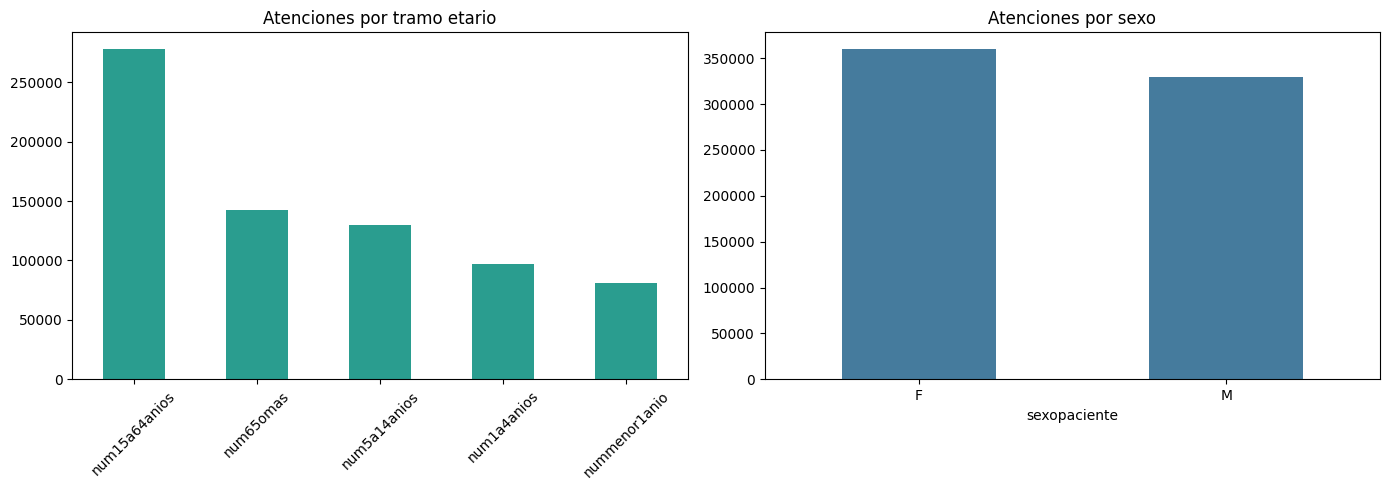

num15a64anios    278071
num65omas        142509
num5a14anios     129688
num1a4anios       97001
nummenor1anio     80956
dtype: int64

sexopaciente
F    360207
M    329218
Name: numtotal, dtype: int64

In [19]:
edad_cols = ['nummenor1anio', 'num1a4anios', 'num5a14anios', 'num15a64anios', 'num65omas']
edad_cols = [c for c in edad_cols if c in df.columns]

edad_totales = df[edad_cols].sum().sort_values(ascending=False) if edad_cols else pd.Series(dtype='float64')
sexo_totales = (
    df.groupby('sexopaciente', dropna=False)['numtotal'].sum().sort_values(ascending=False)
    if {'sexopaciente', 'numtotal'}.issubset(df.columns) else pd.Series(dtype='float64')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if not edad_totales.empty:
    edad_totales.plot(kind='bar', ax=axes[0], color='#2a9d8f')
    axes[0].set_title('Atenciones por tramo etario')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'Sin columnas de edad', ha='center')

if not sexo_totales.empty:
    sexo_totales.plot(kind='bar', ax=axes[1], color='#457b9d')
    axes[1].set_title('Atenciones por sexo')
    axes[1].tick_params(axis='x', rotation=0)
else:
    axes[1].text(0.5, 0.5, 'Sin columnas de sexo/numtotal', ha='center')

plt.tight_layout()
plt.show()
display(edad_totales)
display(sexo_totales)

## 3) Demanda clinica: causas, triage y tipo de urgencia

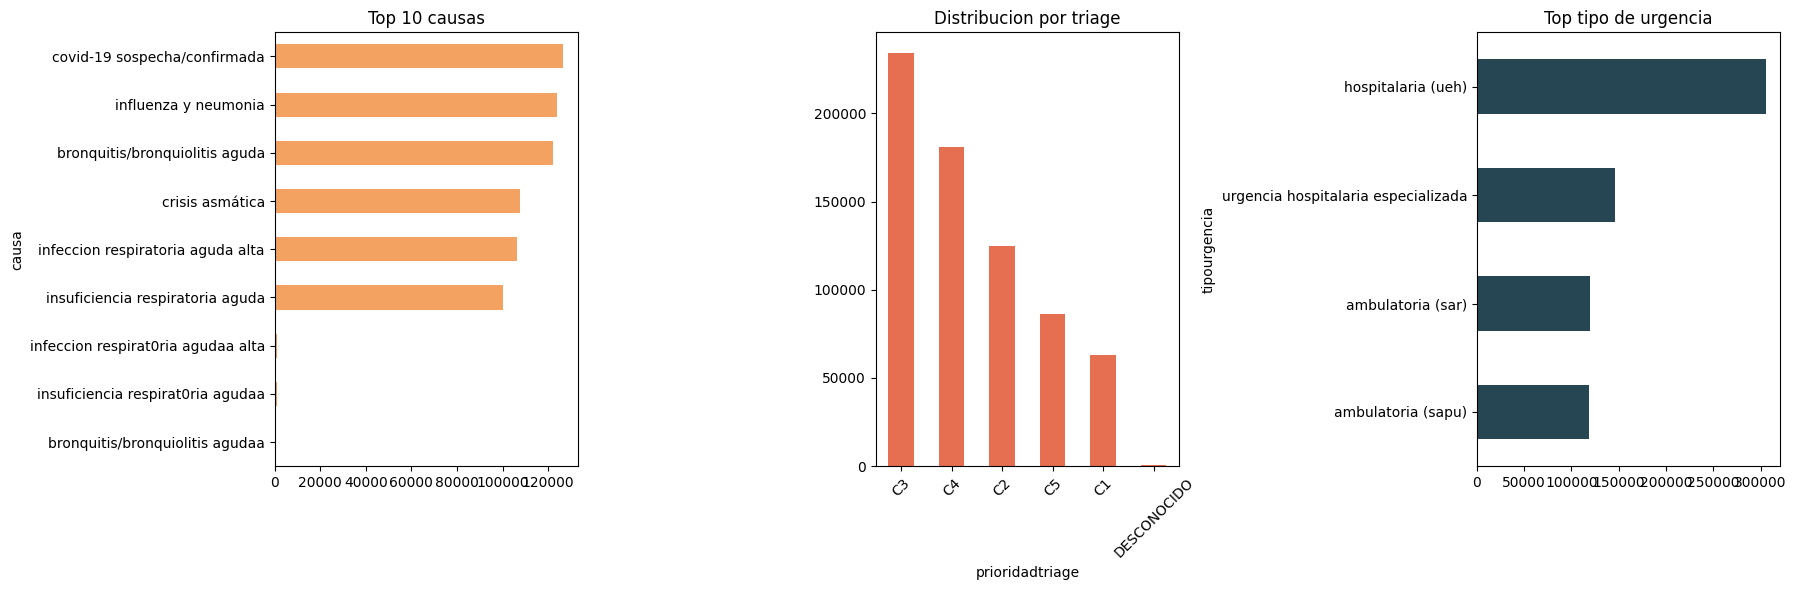

In [20]:
causa_totales = (
    df.groupby('causa')['numtotal'].sum().sort_values(ascending=False)
    if {'causa', 'numtotal'}.issubset(df.columns) else pd.Series(dtype='float64')
)
triage_totales = (
    df.groupby('prioridadtriage')['numtotal'].sum().sort_values(ascending=False)
    if {'prioridadtriage', 'numtotal'}.issubset(df.columns) else pd.Series(dtype='float64')
)
tipo_urgencia_totales = (
    df.groupby('tipourgencia')['numtotal'].sum().sort_values(ascending=False)
    if {'tipourgencia', 'numtotal'}.issubset(df.columns) else pd.Series(dtype='float64')
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
if not causa_totales.empty:
    causa_totales.head(10).sort_values().plot(kind='barh', ax=axes[0], color='#f4a261')
    axes[0].set_title('Top 10 causas')
else:
    axes[0].text(0.5, 0.5, 'Sin causa/numtotal', ha='center')

if not triage_totales.empty:
    triage_totales.plot(kind='bar', ax=axes[1], color='#e76f51')
    axes[1].set_title('Distribucion por triage')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'Sin triage/numtotal', ha='center')

if not tipo_urgencia_totales.empty:
    tipo_urgencia_totales.head(10).sort_values().plot(kind='barh', ax=axes[2], color='#264653')
    axes[2].set_title('Top tipo de urgencia')
else:
    axes[2].text(0.5, 0.5, 'Sin tipourgencia/numtotal', ha='center')

plt.tight_layout()
plt.show()

## 4) Geografia asistencial: regiones y establecimientos

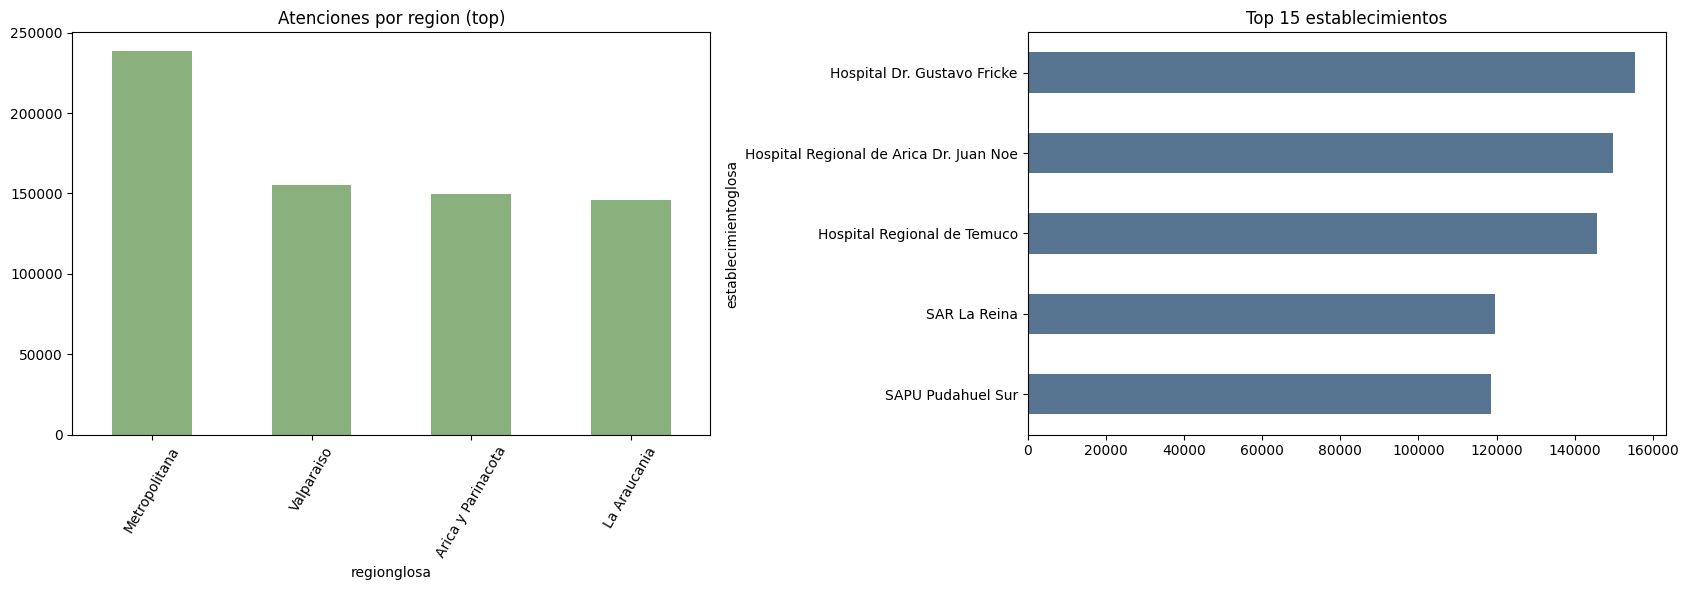

regionglosa
Metropolitana         238315
Valparaiso            155486
Arica y Parinacota    149826
La Araucania          145798
Name: numtotal, dtype: int64

In [21]:
region_totales = (
    df.groupby('regionglosa')['numtotal'].sum().sort_values(ascending=False)
    if {'regionglosa', 'numtotal'}.issubset(df.columns) else pd.Series(dtype='float64')
)
top_establecimientos = (
    df.groupby('establecimientoglosa')['numtotal'].sum().sort_values(ascending=False).head(15)
    if {'establecimientoglosa', 'numtotal'}.issubset(df.columns) else pd.Series(dtype='float64')
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
if not region_totales.empty:
    region_totales.head(12).plot(kind='bar', ax=axes[0], color='#8ab17d')
    axes[0].set_title('Atenciones por region (top)')
    axes[0].tick_params(axis='x', rotation=60)
else:
    axes[0].text(0.5, 0.5, 'Sin region/numtotal', ha='center')

if not top_establecimientos.empty:
    top_establecimientos.sort_values().plot(kind='barh', ax=axes[1], color='#577590')
    axes[1].set_title('Top 15 establecimientos')
else:
    axes[1].text(0.5, 0.5, 'Sin establecimiento/numtotal', ha='center')

plt.tight_layout()
plt.show()
display(region_totales.head(15))

## 5) Analisis economico: costo y costo por paciente

count    4.657000e+03
mean     1.000204e+05
std      5.133842e+04
min      1.500000e+04
25%      7.943000e+04
50%      9.838800e+04
75%      1.171220e+05
max      1.722934e+06
Name: costoatencionclp, dtype: float64

C:\Users\gabog\AppData\Local\Temp\ipykernel_40844\1255760696.py:32: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['costopromedioporpaciente'].replace([np.inf, -np.inf], np.nan, inplace=True)


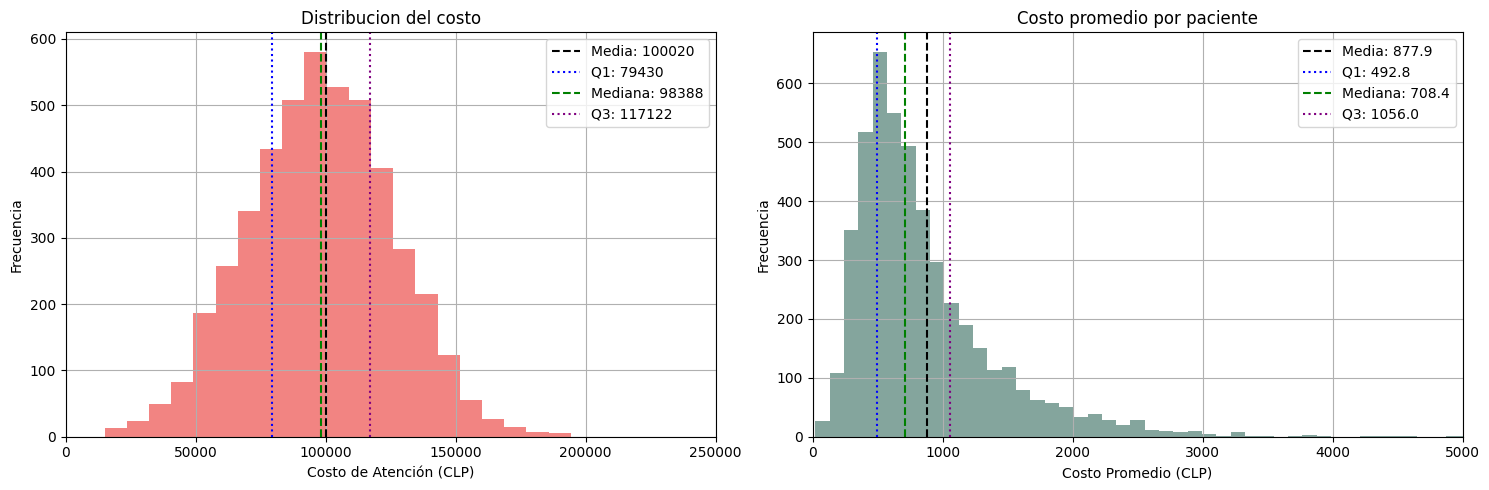


Costo promedio por regionglosa:


regionglosa
Valparaiso            101182.864807
Metropolitana         100806.903226
La Araucania          100272.221865
Arica y Parinacota     97036.189914
Name: costoatencionclp, dtype: float64


Costo promedio por prioridadtriage:


prioridadtriage
C4             103373.554745
C5             100774.378761
C2              99459.174801
DESCONOCIDO     98738.400000
C3              98422.947334
C1              96335.970115
Name: costoatencionclp, dtype: float64


Costo promedio por causa:


causa
insuficiencia respirat0ria agudaa     103169.181818
infeccion respiratoria aguda alta     102986.236979
influenza y neumonia                  101633.350968
crisis asmática                       100458.504493
infeccion respirat0ria agudaa alta     99083.100000
covid-19 sospecha/confirmada           98660.970207
bronquitis/bronquiolitis aguda         98385.580103
insuficiencia respiratoria aguda       97967.570118
bronquitis/bronquiolitis agudaa        97374.800000
Name: costoatencionclp, dtype: float64

In [32]:
if 'costoatencionclp' in df.columns:
    display(df['costoatencionclp'].describe())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # --- Primer histograma: Distribución del costo ---
    costo_data = df['costoatencionclp'].dropna()
    costo_data.hist(bins=200, ax=axes[0], color='#f28482')
    axes[0].set_title('Distribucion del costo')
    axes[0].set_xlim(0, 250000)
    
    # Agregar nombres a los ejes del primer gráfico
    axes[0].set_xlabel('Costo de Atención (CLP)')
    axes[0].set_ylabel('Frecuencia')

    # Calcular media y cuartiles
    media = costo_data.mean()
    q1 = costo_data.quantile(0.25)
    mediana = costo_data.median() # Equivalente a quantile(0.50)
    q3 = costo_data.quantile(0.75)

    # Agregar líneas al primer gráfico
    axes[0].axvline(media, color='black', linestyle='dashed', linewidth=1.5, label=f'Media: {media:.0f}')
    axes[0].axvline(q1, color='blue', linestyle='dotted', linewidth=1.5, label=f'Q1: {q1:.0f}')
    axes[0].axvline(mediana, color='green', linestyle='dashed', linewidth=1.5, label=f'Mediana: {mediana:.0f}')
    axes[0].axvline(q3, color='purple', linestyle='dotted', linewidth=1.5, label=f'Q3: {q3:.0f}')
    axes[0].legend() # Mostrar la leyenda

    # --- Segundo histograma: Costo promedio por paciente ---
    if 'numtotal' in df.columns:
        df['costopromedioporpaciente'] = df['costoatencionclp'] / df['numtotal'].replace(0, np.nan)
        df['costopromedioporpaciente'].replace([np.inf, -np.inf], np.nan, inplace=True)
        
        costo_prom_data = df['costopromedioporpaciente'].dropna()
        costo_prom_data.hist(bins=200, ax=axes[1], color='#84a59d')
        axes[1].set_title('Costo promedio por paciente')
        axes[1].set_xlim(0, 5000)
        
        # Agregar nombres a los ejes del segundo gráfico
        axes[1].set_xlabel('Costo Promedio (CLP)')
        axes[1].set_ylabel('Frecuencia')
        
        # Calcular media y cuartiles para el segundo gráfico
        media_prom = costo_prom_data.mean()
        q1_prom = costo_prom_data.quantile(0.25)
        mediana_prom = costo_prom_data.median()
        q3_prom = costo_prom_data.quantile(0.75)
        
        # Agregar líneas al segundo gráfico
        axes[1].axvline(media_prom, color='black', linestyle='dashed', linewidth=1.5, label=f'Media: {media_prom:.1f}')
        axes[1].axvline(q1_prom, color='blue', linestyle='dotted', linewidth=1.5, label=f'Q1: {q1_prom:.1f}')
        axes[1].axvline(mediana_prom, color='green', linestyle='dashed', linewidth=1.5, label=f'Mediana: {mediana_prom:.1f}')
        axes[1].axvline(q3_prom, color='purple', linestyle='dotted', linewidth=1.5, label=f'Q3: {q3_prom:.1f}')
        axes[1].legend() # Mostrar la leyenda
    else:
        axes[1].text(0.5, 0.5, 'Sin numtotal para calcular costo/paciente', ha='center')

    plt.tight_layout()
    plt.show()

    # --- Tablas agrupadas ---
    for categoria in ['regionglosa', 'prioridadtriage', 'causa']:
        if categoria in df.columns:
            print(f'\nCosto promedio por {categoria}:')
            display(df.groupby(categoria)['costoatencionclp'].mean().sort_values(ascending=False).head(15))
else:
    print('No existe la columna costoatencionclp en el dataset limpio')


## 6) Analisis temporal y relacion causa vs establecimiento

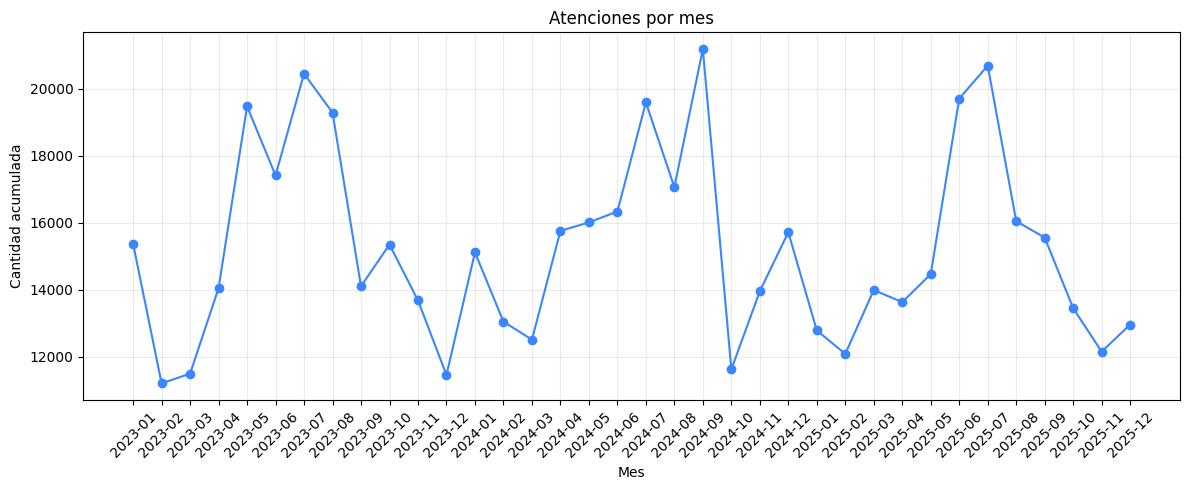

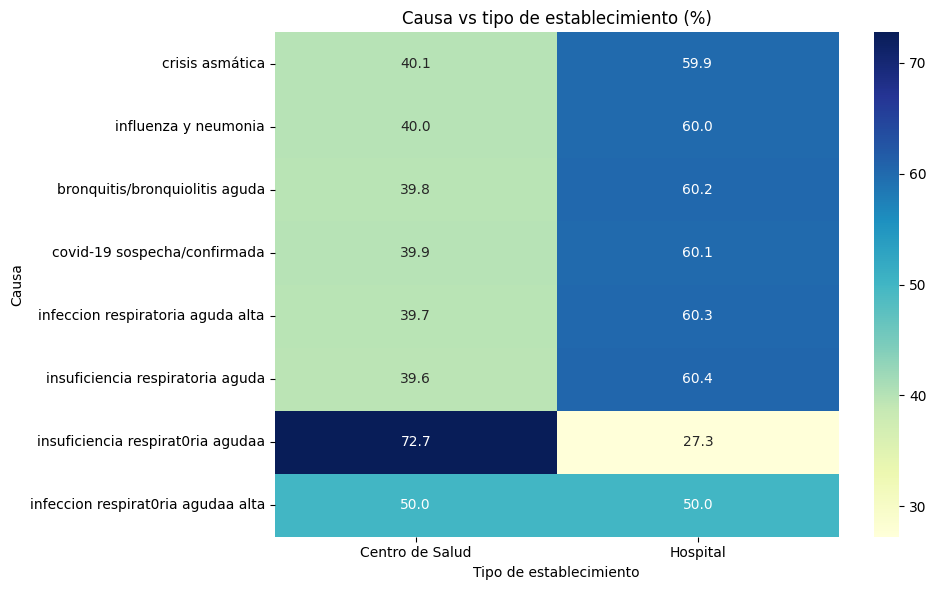

In [23]:
if 'fechaatencion_dt' in df.columns and 'numtotal' in df.columns:
    serie_mes = df.groupby(df['fechaatencion_dt'].dt.to_period('M'))['numtotal'].sum().sort_index()
    plt.figure(figsize=(12, 5))
    plt.plot(serie_mes.index.astype(str), serie_mes.values, marker='o', color='#3a86ff')
    plt.title('Atenciones por mes')
    plt.xlabel('Mes')
    plt.ylabel('Cantidad acumulada')
    plt.xticks(rotation=45)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

if {'causa', 'tipoestablecimiento'}.issubset(df.columns):
    top8 = df['causa'].value_counts().head(8).index
    tabla_rel = pd.crosstab(df['causa'], df['tipoestablecimiento'], normalize='index').loc[top8] * 100
    plt.figure(figsize=(10, 6))
    sns.heatmap(tabla_rel, annot=True, fmt='.1f', cmap='YlGnBu')
    plt.title('Causa vs tipo de establecimiento (%)')
    plt.xlabel('Tipo de establecimiento')
    plt.ylabel('Causa')
    plt.tight_layout()
    plt.show()

## 7) Modelo logistico: Hospital vs Centro de Salud

AUC: 0.458
Matriz confusion [[TN, FP], [FN, TP]]: [[178, 287], [313, 387]]
Accuracy: 0.485
Precision: 0.5742
Recall: 0.5529
F1: 0.5633


,precision,recall,f1-score,support
Centro de Salud,0.36,0.38,0.37,465.0
Hospital,0.57,0.55,0.56,700.0
accuracy,0.48,0.48,0.48,0.0
macro avg,0.47,0.47,0.47,1165.0
weighted avg,0.49,0.48,0.49,1165.0


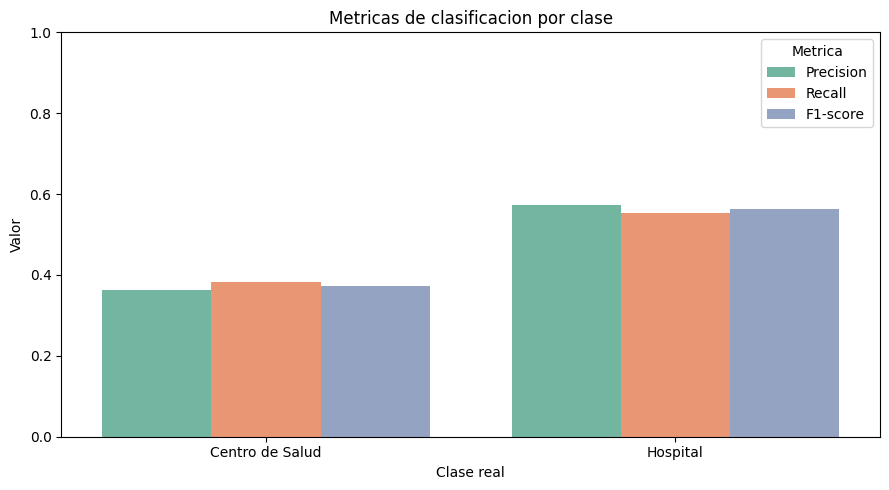

In [24]:
df_modelo = df.copy()
mapa_objetivo = {'hospital': 1, 'centro de salud': 0}

if {'tipoestablecimiento', 'causa', 'fechaatencion_dt'}.issubset(df_modelo.columns):
    df_modelo['tipo_establecimiento_limpio'] = df_modelo['tipoestablecimiento'].astype('string').str.strip().str.lower()
    df_modelo['objetivo_hospital'] = df_modelo['tipo_establecimiento_limpio'].map(mapa_objetivo)

    df_modelo['dia_semana'] = df_modelo['fechaatencion_dt'].dt.day_name()
    df_modelo['mes'] = df_modelo['fechaatencion_dt'].dt.month.astype('Int64').astype('string')
    df_modelo['anio'] = df_modelo['fechaatencion_dt'].dt.year.astype('Int64').astype('string')

    X = df_modelo[['causa', 'dia_semana', 'mes', 'anio']].copy()
    for col in X.columns:
        X[col] = X[col].astype('string').fillna('desconocido')
    y = df_modelo['objetivo_hospital']
    idx = y.notna()
    X = X.loc[idx].copy()
    y = y[idx].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    columnas_categoricas = ['causa', 'dia_semana', 'mes', 'anio']
    preproceso = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
        ]
    )

    modelo = Pipeline(steps=[
        ('prep', preproceso),
        ('logit', LogisticRegression(max_iter=2000, class_weight='balanced'))
    ])

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    met_auc = roc_auc_score(y_test, y_prob)
    mc = confusion_matrix(y_test, y_pred)

    print('AUC:', round(met_auc, 4))
    print('Matriz confusion [[TN, FP], [FN, TP]]:', mc.tolist())
    print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
    print('Precision:', round(precision_score(y_test, y_pred, zero_division=0), 4))
    print('Recall:', round(recall_score(y_test, y_pred, zero_division=0), 4))
    print('F1:', round(f1_score(y_test, y_pred, zero_division=0), 4))

    reporte = classification_report(
        y_test,
        y_pred,
        target_names=['Centro de Salud', 'Hospital'],
        output_dict=True,
        zero_division=0,
    )
    reporte_df = pd.DataFrame(reporte).T
    reporte_df = reporte_df.rename(index={'accuracy': 'accuracy', 'macro avg': 'macro avg', 'weighted avg': 'weighted avg'})
    reporte_df = reporte_df[['precision', 'recall', 'f1-score', 'support']]
    display(reporte_df.round({'precision': 2, 'recall': 2, 'f1-score': 2, 'support': 0}))

    metricas_clase = pd.DataFrame({
        'Clase': ['Centro de Salud', 'Hospital'],
        'Precision': [reporte_df.loc['Centro de Salud', 'precision'], reporte_df.loc['Hospital', 'precision']],
        'Recall': [reporte_df.loc['Centro de Salud', 'recall'], reporte_df.loc['Hospital', 'recall']],
        'F1-score': [reporte_df.loc['Centro de Salud', 'f1-score'], reporte_df.loc['Hospital', 'f1-score']],
    })
    metricas_largas = metricas_clase.melt(id_vars='Clase', var_name='Metrica', value_name='Valor')
    plt.figure(figsize=(9, 5))
    sns.barplot(data=metricas_largas, x='Clase', y='Valor', hue='Metrica', palette='Set2')
    plt.ylim(0, 1)
    plt.title('Metricas de clasificacion por clase')
    plt.ylabel('Valor')
    plt.xlabel('Clase real')
    plt.legend(title='Metrica')
    plt.tight_layout()
    plt.show()
else:
    print('No hay columnas suficientes para ejecutar el modelo logistico')

- Precision: de todas las veces que el modelo dijo una clase, cuántas veces acertó.
- Recall: de todos los casos reales de esa clase, cuántos detectó.
- F1-score: combina precision y recall en un solo valor.

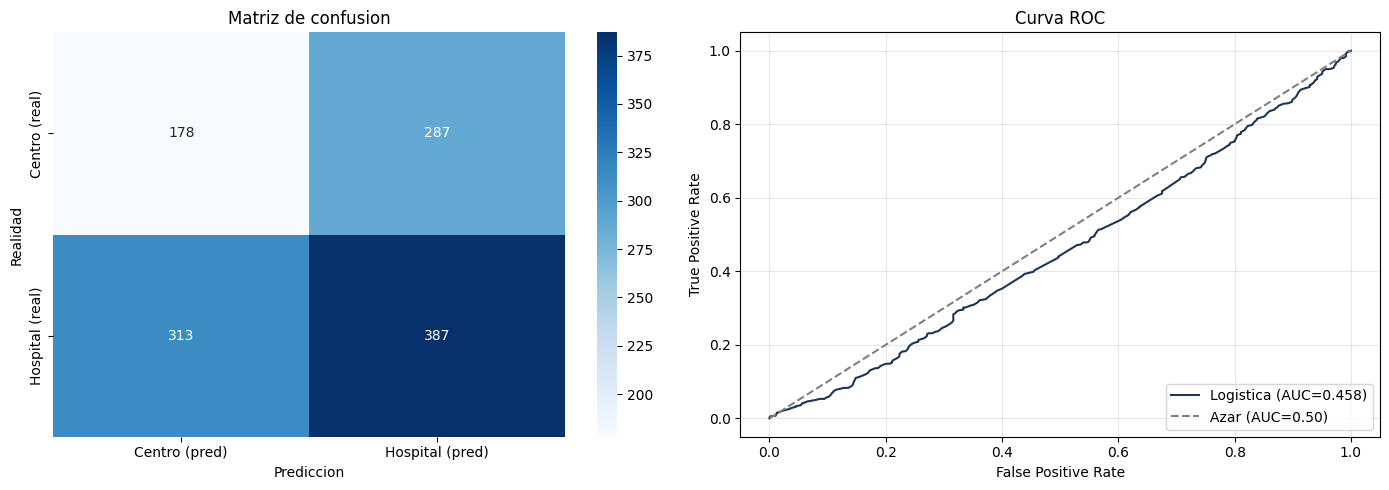

,variable,coeficiente
7,causa_insuficiencia respirat0ria agudaa,-0.838380
4,causa_infeccion respirat0ria agudaa alta,-0.332707
2,causa_covid-19 sospecha/confirmada,0.212471
6,causa_influenza y neumonia,0.210365
3,causa_crisis asmática,0.209447
5,causa_infeccion respiratoria aguda alta,0.190212
0,causa_bronquitis/bronquiolitis aguda,0.178337
8,causa_insuficiencia respiratoria aguda,0.172602
14,mes_12,-0.159623
20,mes_7,-0.150093


In [25]:
if 'mc' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        mc,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Centro (pred)', 'Hospital (pred)'],
        yticklabels=['Centro (real)', 'Hospital (real)'],
        ax=axes[0]
    )
    axes[0].set_title('Matriz de confusion')
    axes[0].set_xlabel('Prediccion')
    axes[0].set_ylabel('Realidad')

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_plot = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'Logistica (AUC={auc_plot:.3f})', color='#1d3557')
    axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Azar (AUC=0.50)')
    axes[1].set_title('Curva ROC')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    onehot = modelo.named_steps['prep'].named_transformers_['cat']
    nombres = onehot.get_feature_names_out(['causa', 'dia_semana', 'mes', 'anio'])
    coefs = modelo.named_steps['logit'].coef_[0]
    tabla_coef = pd.DataFrame({'variable': nombres, 'coeficiente': coefs, 'magnitud': np.abs(coefs)})
    display(tabla_coef.sort_values('magnitud', ascending=False).head(10)[['variable', 'coeficiente']])

## 8) Resumen ejecutivo integrado

Hallazgos mas utiles del analisis unificado:
1. Se consolido una limpieza robusta con control de nulos, duplicados y normalizacion de categorias clave.
2. La demanda se concentra en tramos etarios especificos y muestra diferencias por sexo.
3. Existen causas dominantes y distribuciones de triage que permiten priorizar gestion clinica.
4. Se observan concentraciones territoriales por region y por establecimiento.
5. El costo presenta dispersion y cambia segun region, triage y causa.
6. El patron mensual permite detectar estacionalidad en la demanda.
7. El modelo logistico aporta interpretabilidad (matriz y coeficientes), y su AUC permite discutir capacidad explicativa real con las variables disponibles.
